#  Adaboost: A Complete Notebook

---

## What You'll Learn
By the end of this notebook, you will understand:
- What **ensemble learning** is and why it works
- The **intuition behind AdaBoost** (Adaptive Boosting)
- How AdaBoost **trains weak learners** step by step
- How to **implement AdaBoost from scratch** in Python
- How to use **scikit-learn's AdaBoost** for real-world tasks
- When AdaBoost **works well** and when it **doesn't**

---

## Part 1: The Big Picture — What is Boosting?

### The Wisdom of the Crowd (but smarter)

Imagine you want to identify whether an email is spam. Instead of asking one "super-expert", you ask a group of simple rules:

- Rule 1: "Does it contain the word 'FREE'?"
- Rule 2: "Is the sender unknown?"
- Rule 3: "Does it have lots of exclamation marks?"

Each rule alone is **weak** and makes mistakes. But combined cleverly, they form a **strong classifier**.

This is the **core idea of Boosting**: combine many weak learners into one strong learner.

### What Makes Boosting Different from Bagging (e.g., Random Forests)?

| Feature | Bagging (Random Forest) | Boosting (AdaBoost) |
|---|---|---|
| Learners trained | In **parallel** | **Sequentially** |
| Focus | Reduce variance | Reduce bias |
| Mistakes handled | Each tree ignores others | Next learner **focuses on mistakes** |
| Voting | Equal weight | **Weighted** by accuracy |

---

## Part 2: AdaBoost — The Intuition

### The "Struggling Student" Analogy

Think of training like tutoring a student:

1. **Round 1**: The student takes a test. Some questions are answered correctly, some are not.
2. **Round 2**: You focus the student on the **questions they got wrong** — those get more attention.
3. **Round 3**: Some of the previously wrong questions are now correct, but new ones might be wrong. Focus again.
4. **Final Exam**: The student's overall grade is a **weighted combination** of performance across all rounds.

In AdaBoost:
- The "student" = a weak learner (usually a **Decision Stump** — a tree with depth 1)
- "Focusing on wrong questions" = **increasing the weights** of misclassified samples
- "Weighted combination" = final prediction uses **weighted voting** of all weak learners

### The 3 Key Ideas

1. **Sample Weights**: Every training sample starts with equal importance. Misclassified samples get **higher weight** in the next round.
2. **Learner Weights**: Weak learners that perform better get **more say** in the final vote.
3. **Sequential Learning**: Each learner tries to fix what the **previous learners got wrong**.

---

## Part 3: The Algorithm — Step by Step

Here's the AdaBoost algorithm in plain English:

```
GIVEN: Training data with N samples, T rounds

Step 0: Assign equal weight to every sample → weight = 1/N

FOR each round t = 1, 2, ..., T:

    Step 1: Train a weak learner on the WEIGHTED training data
    
    Step 2: Calculate the learner's weighted error
             (how many weighted samples were misclassified)
    
    Step 3: Calculate the learner's weight (alpha)
             - If error is low → alpha is HIGH (this learner is trusted more)
             - If error is high → alpha is LOW (this learner is trusted less)
    
    Step 4: Update sample weights
             - Misclassified samples → INCREASE their weight
             - Correctly classified → DECREASE their weight
    
    Step 5: Normalize weights so they sum to 1

FINAL PREDICTION: Weighted vote of all weak learners
```

---

## Part 4: Setup & Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification, make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

print("All imports successful!")

All imports successful!


## Part 5: Understanding Decision Stumps (The Weak Learner)

AdaBoost typically uses **Decision Stumps** as weak learners.

A Decision Stump is a Decision Tree with **max_depth=1**. It makes a single split:
- "Is feature X > threshold?"
  - YES → predict class A
  - NO → predict class B

It's intentionally simple (weak), but it's better than random guessing.

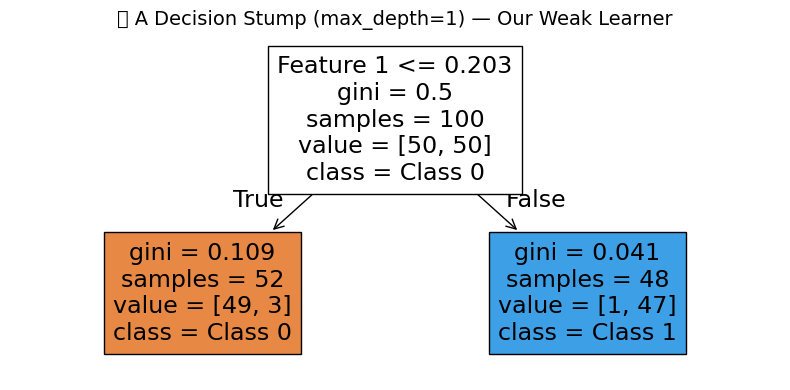

Stump accuracy on its own: 96.00%

A stump alone is weak, but AdaBoost combines many of them!


In [3]:
# Visualize a Decision Stump
from sklearn.datasets import make_classification
from sklearn.tree import plot_tree

X_demo, y_demo = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                      n_informative=2, random_state=42)

# Train a stump
stump = DecisionTreeClassifier(max_depth=1)
stump.fit(X_demo, y_demo)

fig, ax = plt.subplots(figsize=(8, 4))
plot_tree(stump, feature_names=['Feature 1', 'Feature 2'],
          class_names=['Class 0', 'Class 1'], filled=True, ax=ax)
plt.title("🌿 A Decision Stump (max_depth=1) — Our Weak Learner", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Stump accuracy on its own: {accuracy_score(y_demo, stump.predict(X_demo)):.2%}")
print("\nA stump alone is weak, but AdaBoost combines many of them!")

## Part 6: AdaBoost From Scratch

Let's build AdaBoost step by step. We'll use a simple 1D example first so we can visualize everything clearly.

### Step 6.1: Create a Simple Dataset

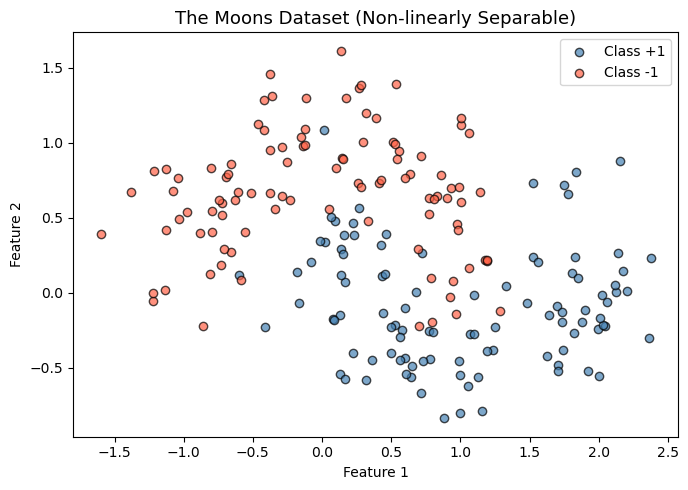

Training samples: 140 | Test samples: 60


In [5]:
# Simple 2D dataset for visualization
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)
y = np.where(y == 0, -1, 1)  # AdaBoost uses -1 and +1 labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualize
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='steelblue', label='Class +1', alpha=0.7, edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='tomato', label='Class -1', alpha=0.7, edgecolors='k')
plt.title("The Moons Dataset (Non-linearly Separable)", fontsize=13)
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

### Step 6.2: The Full AdaBoost Implementation

In [6]:
class AdaBoostFromScratch:
    """
    AdaBoost Classifier built from scratch.
    Uses Decision Stumps (max_depth=1) as weak learners.
    Labels must be -1 and +1.
    """
    
    def __init__(self, n_estimators=50):
        """
        n_estimators: How many weak learners to train (rounds of boosting)
        """
        self.n_estimators = n_estimators
        self.stumps = []          # List of trained weak learners
        self.stump_weights = []   # Alpha values (how much each stump is trusted)
        self.errors = []          # Track error at each round
        self.sample_weights_history = []  # Track how weights evolve
    
    def fit(self, X, y):
        n_samples = len(y)
        
        # ─── Step 0: Initialize equal weights ───
        weights = np.ones(n_samples) / n_samples
        
        for t in range(self.n_estimators):
            
            # ─── Step 1: Train a weak learner on weighted data ───
            # We pass sample_weight so the stump "cares more" about high-weight samples
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=weights)
            predictions = stump.predict(X)
            
            # ─── Step 2: Calculate weighted error ───
            # Sum of weights for MISCLASSIFIED samples
            incorrect = (predictions != y)
            weighted_error = np.sum(weights[incorrect])
            
            # Clip to avoid log(0) issues
            weighted_error = np.clip(weighted_error, 1e-10, 1 - 1e-10)
            
            # ─── Step 3: Calculate stump weight (alpha) ───
            # Better stumps (lower error) get higher alpha
            # alpha = 0.5 * log((1 - error) / error)
            alpha = 0.5 * np.log((1 - weighted_error) / weighted_error)
            
            # ─── Step 4: Update sample weights ───
            # - MISCLASSIFIED samples: multiply by e^(+alpha) → weight INCREASES
            # - CORRECTLY classified: multiply by e^(-alpha) → weight DECREASES
            weights = weights * np.exp(-alpha * y * predictions)
            
            # ─── Step 5: Normalize weights so they sum to 1 ───
            weights = weights / np.sum(weights)
            
            # Store everything
            self.stumps.append(stump)
            self.stump_weights.append(alpha)
            self.errors.append(weighted_error)
            self.sample_weights_history.append(weights.copy())
        
        return self
    
    def predict(self, X):
        """
        Final prediction = sign of the weighted sum of all stump predictions
        """
        # Each stump votes, weighted by its alpha
        weighted_sum = np.zeros(len(X))
        
        for stump, alpha in zip(self.stumps, self.stump_weights):
            weighted_sum += alpha * stump.predict(X)
        
        # Sign: positive sum → class +1, negative sum → class -1
        return np.sign(weighted_sum)
    
    def staged_accuracy(self, X, y):
        """
        Calculate accuracy after each boosting round.
        Useful for seeing how performance improves over time.
        """
        accuracies = []
        weighted_sum = np.zeros(len(X))
        
        for stump, alpha in zip(self.stumps, self.stump_weights):
            weighted_sum += alpha * stump.predict(X)
            preds = np.sign(weighted_sum)
            accuracies.append(accuracy_score(y, preds))
        
        return accuracies

print("✅ AdaBoostFromScratch class defined!")

✅ AdaBoostFromScratch class defined!


### Step 6.3: Train Our Custom AdaBoost

In [7]:
# Train our custom AdaBoost
ada = AdaBoostFromScratch(n_estimators=50)
ada.fit(X_train, y_train)

# Evaluate
train_preds = ada.predict(X_train)
test_preds = ada.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"📊 Results after 50 boosting rounds:")
print(f"   Training Accuracy : {train_acc:.2%}")
print(f"   Test Accuracy     : {test_acc:.2%}")

print(f"\n🔍 Weak learner weights (first 10 alphas):")
for i, alpha in enumerate(ada.stump_weights[:10]):
    print(f"   Round {i+1:2d}: alpha = {alpha:.4f}  |  error = {ada.errors[i]:.4f}")

📊 Results after 50 boosting rounds:
   Training Accuracy : 98.57%
   Test Accuracy     : 91.67%

🔍 Weak learner weights (first 10 alphas):
   Round  1: alpha = 0.8133  |  error = 0.1643
   Round  2: alpha = 0.5064  |  error = 0.2664
   Round  3: alpha = 0.5967  |  error = 0.2326
   Round  4: alpha = 0.5172  |  error = 0.2623
   Round  5: alpha = 0.3443  |  error = 0.3344
   Round  6: alpha = 0.2130  |  error = 0.3951
   Round  7: alpha = 0.5436  |  error = 0.2522
   Round  8: alpha = 0.3444  |  error = 0.3343
   Round  9: alpha = 0.4420  |  error = 0.2924
   Round 10: alpha = 0.3023  |  error = 0.3533


## Part 7: Visualizing How AdaBoost Works

### 7.1: How Accuracy Improves Over Rounds

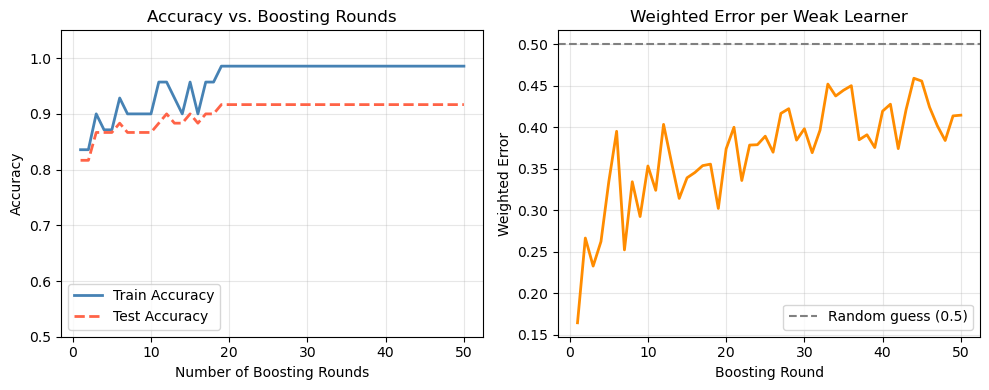

Notice: Each weak learner has error < 0.5 (better than random)
Together, they produce a much stronger classifier!


In [12]:
train_accs = ada.staged_accuracy(X_train, y_train)
test_accs = ada.staged_accuracy(X_test, y_test)

rounds = range(1, len(train_accs) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(rounds, train_accs, label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(rounds, test_accs, label='Test Accuracy', color='tomato', linewidth=2, linestyle='--')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Boosting Rounds')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.5, 1.05])

plt.subplot(1, 2, 2)
plt.plot(rounds, ada.errors, color='darkorange', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', label='Random guess (0.5)')
plt.xlabel('Boosting Round')
plt.ylabel('Weighted Error')
plt.title('Weighted Error per Weak Learner')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: Each weak learner has error < 0.5 (better than random)")
print("Together, they produce a much stronger classifier!")

### 7.2: How Sample Weights Change Over Rounds

This is the **core mechanic** of AdaBoost. Watch how misclassified samples get more weight!

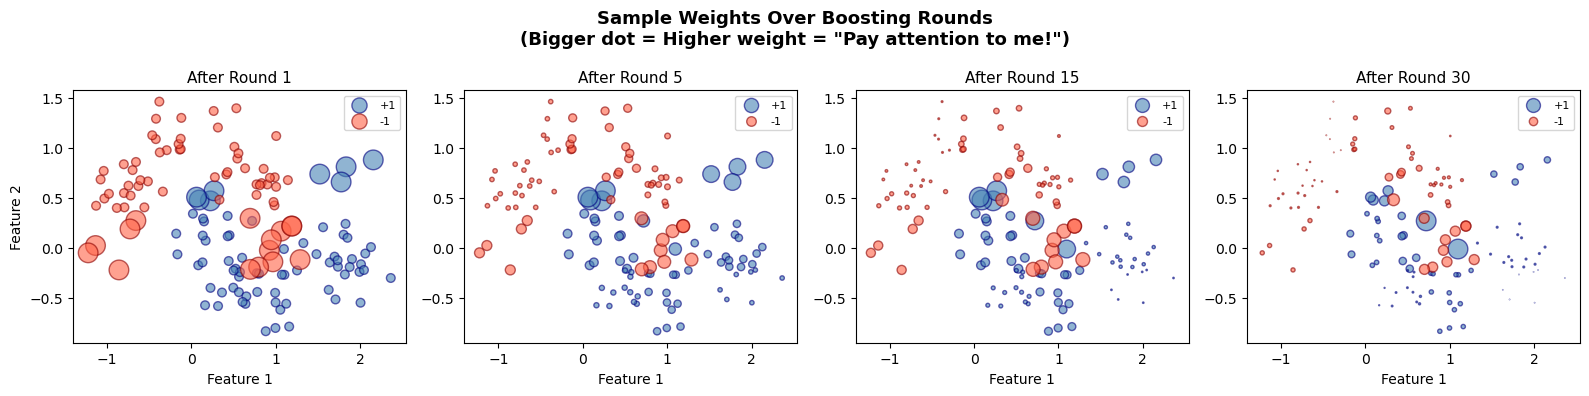

In [13]:
# Show sample weights at rounds 1, 5, 15, 30
rounds_to_show = [0, 4, 14, 29]  # 0-indexed
round_labels = ['After Round 1', 'After Round 5', 'After Round 15', 'After Round 30']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, round_idx, label in zip(axes, rounds_to_show, round_labels):
    weights = ada.sample_weights_history[round_idx]
    # Scale weights for visualization
    scaled = weights / weights.max() * 200
    
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
               s=scaled[y_train == 1], color='steelblue', alpha=0.6, edgecolors='navy', label='+1')
    ax.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1],
               s=scaled[y_train == -1], color='tomato', alpha=0.6, edgecolors='darkred', label='-1')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Feature 2')
fig.suptitle('Sample Weights Over Boosting Rounds\n(Bigger dot = Higher weight = "Pay attention to me!")',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3: Decision Boundary Evolution

Let's see how the decision boundary changes as we add more stumps.

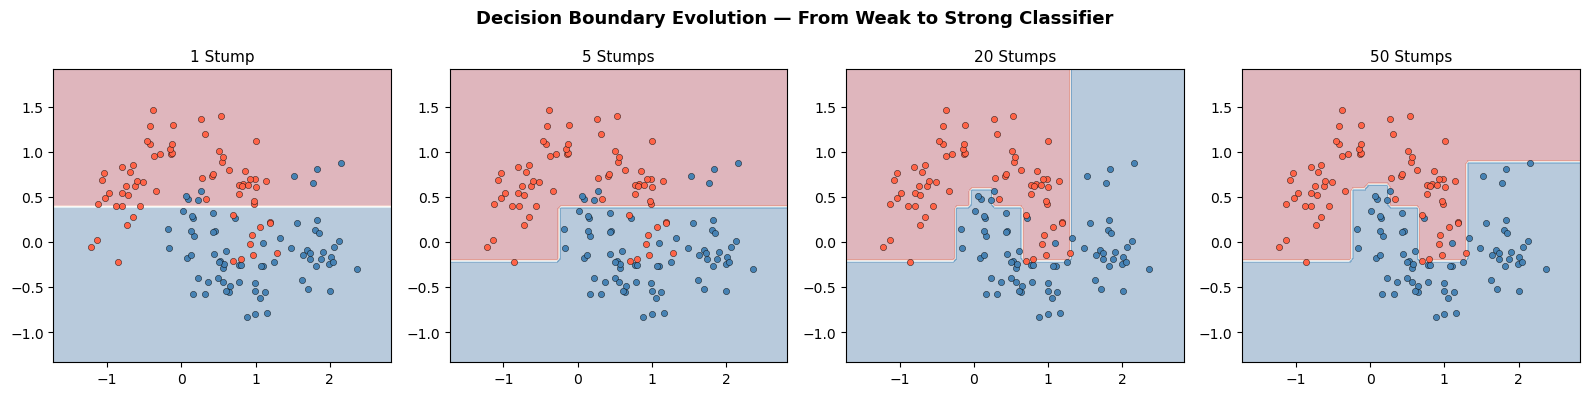


Key observation: A single stump makes a straight-line cut.
As we add more stumps, the boundary becomes more complex and accurate!


In [14]:
def plot_decision_boundary(model, X, y, n_stumps, ax, title):
    """Plot the decision boundary of the first n_stumps of a model."""
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    
    # Use only first n_stumps
    grid = np.c_[xx.ravel(), yy.ravel()]
    weighted_sum = np.zeros(len(grid))
    for stump, alpha in zip(model.stumps[:n_stumps], model.stump_weights[:n_stumps]):
        weighted_sum += alpha * stump.predict(grid)
    Z = np.sign(weighted_sum).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='steelblue', s=20, edgecolors='k', linewidths=0.3)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], color='tomato', s=20, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n, title in zip(axes,
                         [1, 5, 20, 50],
                         ['1 Stump', '5 Stumps', '20 Stumps', '50 Stumps']):
    plot_decision_boundary(ada, X_train, y_train, n, ax, title)

fig.suptitle('Decision Boundary Evolution — From Weak to Strong Classifier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observation: A single stump makes a straight-line cut.")
print("As we add more stumps, the boundary becomes more complex and accurate!")

## Part 8: Using Scikit-Learn's AdaBoost

Now that we understand the internals, let's use the production-ready implementation from scikit-learn.

In [15]:
# Sklearn's AdaBoost — labels can be 0 and 1 (standard)
y_std = np.where(y == -1, 0, 1)  # Convert back to 0/1
X_tr, X_te, y_tr, y_te = train_test_split(X, y_std, test_size=0.3, random_state=42)

# Create AdaBoost with a decision stump base learner
sklearn_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Weak learner
    n_estimators=50,                                # Number of boosting rounds
    learning_rate=1.0,                             # Shrinks each learner's contribution
    algorithm='SAMME',                             # Classic AdaBoost
    random_state=42
)

sklearn_ada.fit(X_tr, y_tr)

print("📊 Scikit-Learn AdaBoost Results:")
print(f"   Train Accuracy: {sklearn_ada.score(X_tr, y_tr):.2%}")
print(f"   Test Accuracy : {sklearn_ada.score(X_te, y_te):.2%}")
print(f"\n📋 Classification Report:")
print(classification_report(y_te, sklearn_ada.predict(X_te)))

📊 Scikit-Learn AdaBoost Results:
   Train Accuracy: 98.57%
   Test Accuracy : 91.67%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        32
           1       0.96      0.86      0.91        28

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.92        60
weighted avg       0.92      0.92      0.92        60



### Key Parameters Explained

| Parameter | What it does | Typical Range |
|---|---|---|
| `n_estimators` | Number of boosting rounds | 50–500 |
| `learning_rate` | Shrinks each learner's contribution (regularization) | 0.01–1.0 |
| `estimator` | The weak learner to boost | Usually DecisionTree(max_depth=1) |
| `algorithm` | 'SAMME' (discrete) | Prefer SAMME |

> 💡 **Tip**: `n_estimators` and `learning_rate` trade off against each other. Lower learning rate → need more estimators.

## Part 9: Effect of Number of Estimators (Hyperparameter Tuning)

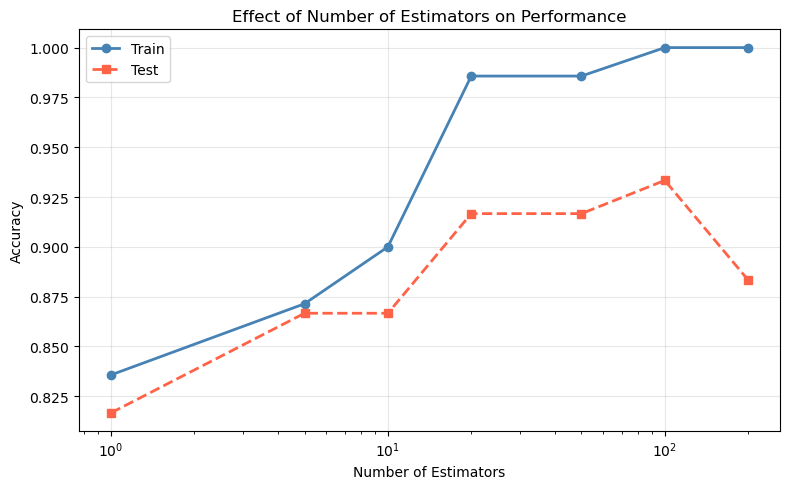

Observation: More estimators generally help, but returns diminish.
AdaBoost is relatively resistant to overfitting (unlike deep trees).


In [16]:
estimator_counts = [1, 5, 10, 20, 50, 100, 200]
train_scores, test_scores = [], []

for n in estimator_counts:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n, algorithm='SAMME', random_state=42
    )
    model.fit(X_tr, y_tr)
    train_scores.append(model.score(X_tr, y_tr))
    test_scores.append(model.score(X_te, y_te))

plt.figure(figsize=(8, 5))
plt.plot(estimator_counts, train_scores, 'o-', label='Train', color='steelblue', linewidth=2)
plt.plot(estimator_counts, test_scores, 's--', label='Test', color='tomato', linewidth=2)
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Effect of Number of Estimators on Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

print("Observation: More estimators generally help, but returns diminish.")
print("AdaBoost is relatively resistant to overfitting (unlike deep trees).")

## Part 10: Real-World Example — Breast Cancer Dataset

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

# Compare: Single tree vs AdaBoost
models = {
    'Decision Stump (1 level)': DecisionTreeClassifier(max_depth=1),
    'Decision Tree (full)': DecisionTreeClassifier(),
    'AdaBoost (50 stumps)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50, algorithm='SAMME', random_state=42
    ),
    'AdaBoost (200 stumps)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=200, algorithm='SAMME', random_state=42
    ),
}

print("📊 Breast Cancer Classification Comparison")
print("-" * 50)
print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train_bc, y_train_bc)
    tr_acc = model.score(X_train_bc, y_train_bc)
    te_acc = model.score(X_test_bc, y_test_bc)
    print(f"{name:<30} {tr_acc:>9.2%} {te_acc:>9.2%}")

print("-" * 50)
print("\n✅ AdaBoost significantly outperforms a single stump!")

📊 Breast Cancer Classification Comparison
--------------------------------------------------
Model                           Train Acc   Test Acc
--------------------------------------------------
Decision Stump (1 level)          92.09%    89.47%
Decision Tree (full)             100.00%    94.74%
AdaBoost (50 stumps)             100.00%    96.49%
AdaBoost (200 stumps)            100.00%    97.37%
--------------------------------------------------

✅ AdaBoost significantly outperforms a single stump!


## Part 11: Feature Importance in AdaBoost

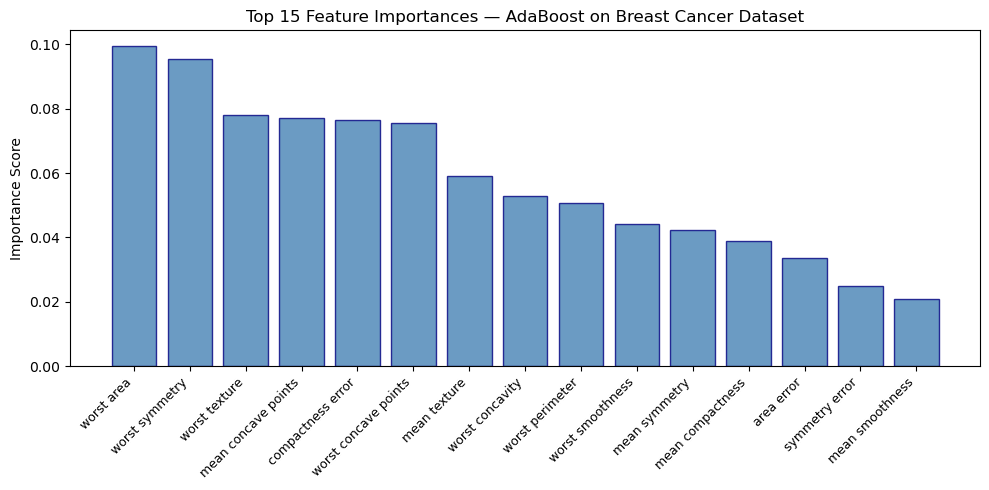

Feature importances tell us which features the stumps used most often.
Top feature: worst area (0.099)


In [18]:
# Train final model on breast cancer
final_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, algorithm='SAMME', random_state=42
)
final_model.fit(X_train_bc, y_train_bc)

# Feature importances
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[indices], color='steelblue', edgecolor='navy', alpha=0.8)
plt.xticks(range(15), [data.feature_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
plt.ylabel('Importance Score')
plt.title('Top 15 Feature Importances — AdaBoost on Breast Cancer Dataset', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature importances tell us which features the stumps used most often.")
print(f"Top feature: {data.feature_names[indices[0]]} ({importances[indices[0]]:.3f})")

## 📖 Part 12: AdaBoost Strengths & Weaknesses

### ✅ When to Use AdaBoost

AdaBoost works well when:
- You have **clean data** (it's sensitive to outliers and noise)
- Your weak learners are **slightly better than random** (error < 0.5)
- You want **interpretable feature importance**
- You're working on **tabular/structured data**
- You want an **ensemble without heavy tuning**

### ❌ Limitations

- **Sensitive to outliers and noise**: Mislabeled data gets very high weight and hurts performance
- **Slower than bagging**: Sequential training can't be parallelized
- **Less powerful than Gradient Boosting** (XGBoost, LightGBM) on most benchmarks
- **Doesn't naturally handle missing values**

### 📊 AdaBoost vs. Other Boosting Methods

| Algorithm | Key Difference | Best For |
|---|---|---|
| **AdaBoost** | Adjusts sample weights | Baseline, interpretability |
| **Gradient Boosting** | Fits residuals (errors) | General purpose |
| **XGBoost** | Gradient boosting + regularization | Kaggle competitions, tabular data |
| **LightGBM** | Leaf-wise tree growth | Large datasets, speed |

---

## Part 13: Demonstrating Sensitivity to Noisy Data

Let's see how AdaBoost handles noisy labels (mislabeled samples).

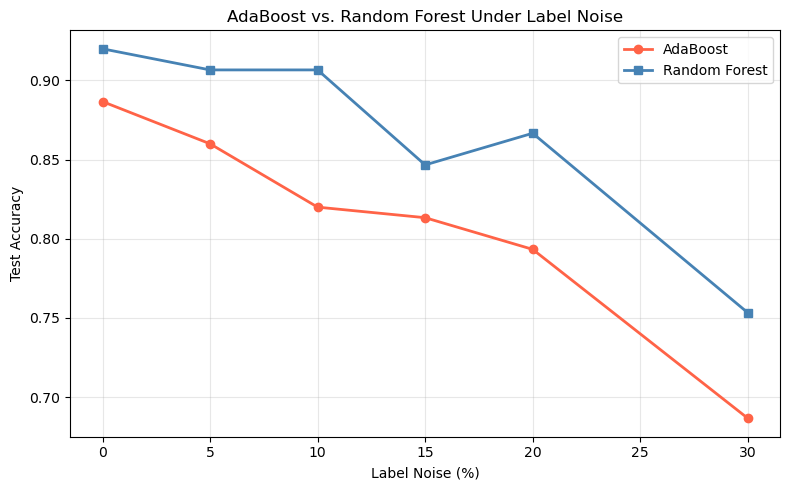

Key insight: AdaBoost's performance degrades faster with noisy labels.
This is because noisy samples get very high weights, misleading future learners.


In [19]:
from sklearn.ensemble import RandomForestClassifier

noise_levels = [0, 0.05, 0.10, 0.15, 0.20, 0.30]

ada_scores = []
rf_scores = []

X_clean, y_clean = make_classification(n_samples=500, n_features=10,
                                         n_informative=5, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

for noise in noise_levels:
    # Flip labels randomly to simulate noise
    y_noisy = y_tr_c.copy()
    n_flip = int(noise * len(y_noisy))
    flip_idx = np.random.choice(len(y_noisy), n_flip, replace=False)
    y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
    
    ada_m = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                n_estimators=50, algorithm='SAMME', random_state=42)
    rf_m = RandomForestClassifier(n_estimators=50, random_state=42)
    
    ada_m.fit(X_tr_c, y_noisy)
    rf_m.fit(X_tr_c, y_noisy)
    
    ada_scores.append(ada_m.score(X_te_c, y_te_c))
    rf_scores.append(rf_m.score(X_te_c, y_te_c))

plt.figure(figsize=(8, 5))
plt.plot([n*100 for n in noise_levels], ada_scores, 'o-', label='AdaBoost', color='tomato', linewidth=2)
plt.plot([n*100 for n in noise_levels], rf_scores, 's-', label='Random Forest', color='steelblue', linewidth=2)
plt.xlabel('Label Noise (%)')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost vs. Random Forest Under Label Noise')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: AdaBoost's performance degrades faster with noisy labels.")
print("This is because noisy samples get very high weights, misleading future learners.")

## 📖 Part 14: Summary & Key Takeaways

### What We Learned

1. **AdaBoost = Adaptive Boosting**: It adapts by focusing on what previous learners got wrong.

2. **Three core mechanics**:
   - Sample weights: Misclassified → higher weight → more focus next round
   - Learner weights (alpha): Better learners get more voting power
   - Sequential training: Each learner corrects the previous

3. **Weak learners → Strong classifier**: Many simple stumps combine into a complex, accurate model

4. **Sensitive to noise**: AdaBoost can overfit to mislabeled data because it keeps increasing their weights

5. **Great baseline**: Simple, interpretable, and often surprisingly effective

### The Algorithm at a Glance

```
Initialize: equal weights for all samples

For each round:
    1. Train weak learner on weighted data
    2. Calculate weighted error
    3. Assign learner weight (alpha) based on error
    4. Increase weights of misclassified samples
    5. Normalize weights

Predict: Weighted vote of all weak learners
```

---


### 📚 Further Reading

- Original AdaBoost paper: Freund & Schapire (1997) — *"A Decision-Theoretic Generalization of On-Line Learning"*
- Scikit-learn docs: [AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)
- Next steps: Gradient Boosting → XGBoost → LightGBM